In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def detect_circles(gray):
    """Обнаруживает все круги на изображении с заданным диапазоном радиусов"""
    rads = np.linspace(0, 80, 8, dtype=int)
    all_circles = []

    for rad in rads:
        detected_circles = cv.HoughCircles(gray,
                    cv.HOUGH_GRADIENT_ALT,
                    dp = 1.5,  # Inverse ratio of the accumulator resolution to the image resolution
                    minDist = (rad + 1) * 2, # Minimum distance between the centers of the detected circles
                    param1 = 300, # The threshold for Scharr detector
                    param2 = 0.9,  # The perfectness of circle
                    minRadius = rad+1, maxRadius = rad+10)

        if detected_circles is not None:
            all_circles.extend(detected_circles[0])

    all_circles = np.array([all_circles])

    return all_circles

In [3]:
def count_pipes(image, all_circles):
    """Считает и отрисовывает трубы"""
    pipes_count = 0
    if all_circles is not None:
        all_circles = np.uint16(np.around(all_circles))

        for points in all_circles[0, :]:
            a, b, r = points[0], points[1], points[2]

            cv.circle(image, (a, b), r, (0, 255, 0), 2)

            cv.circle(image, (a, b), 1, (255, 0, 0), 3)

            pipes_count += 1

    print("Всего труб: ", pipes_count)
    plt.imshow(image)

In [4]:
def detect_pipes(image_path):
    """Основаня функция подсчёта труб"""
    image = cv.imread(image_path)
    image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

    gray = cv.cvtColor(image, cv.COLOR_RGB2GRAY)
    gray = cv.blur(gray, (3, 3))
    
    all_circles = detect_circles(gray)

    count_pipes(image, all_circles)

# pipes-1

Всего труб:  68


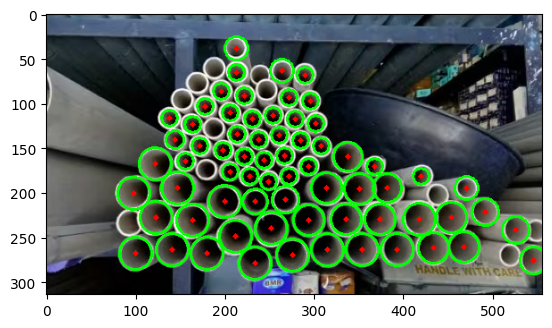

In [5]:
detect_pipes("images/pipes-1.jpg")

# pipes-2

Всего труб:  93


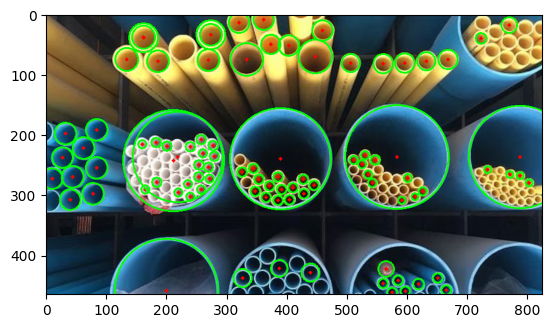

In [6]:
detect_pipes("images/pipes-2.jpg")

# pipes-3

Всего труб:  83


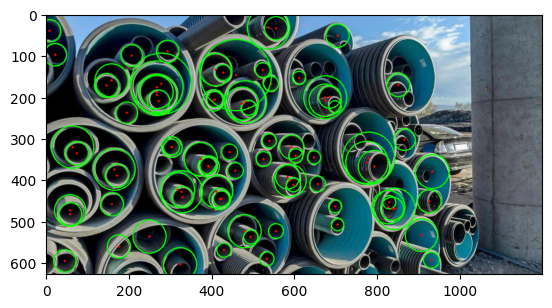

In [7]:
detect_pipes("images/pipes-3.jpg")

### P.S. постобработка и фильтрация не приводили к улучшению результата. Чаще всего с правильно отфильтрованными трубами удалялись и правильно выделенные.